In [18]:
import importlib
import aaro_draft
import pandas as pd
import matplotlib.pyplot as plt
import Conor
from IPython.display import Image, display
from joblib import Parallel, delayed
import Conor as c


# Reward 1

In [19]:
import importlib
importlib.reload(c)

<module 'Conor' from '/workspaces/Research-Skills-for-Financial-Mathematics/Conor.py'>

In [20]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]
#scalings = [5]
configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -38.054

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -36.991

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -35.646

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -29.939

--- Running: scaling=1 ---
    Done. Final mean VPI: -19.520

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.752

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.864

--- Running: scaling=50 ---
    Done. Final mean VPI: -59.825

--- Running: scaling=100 ---
    Done. Final mean VPI: -99.559

--- Running: scaling=500 ---
    Done. Final mean VPI: -150.856


In [21]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-75344.955080,-38.053637,218.5,218.110
1,0.05,-73243.998438,-36.990619,218.5,218.500
2,0.10,-70565.595106,-35.645638,217.6,217.543
3,0.50,-60578.319493,-29.939380,216.7,216.700
4,1.00,-41346.277032,-19.519694,218.5,218.335
5,5.00,-14688.899601,-3.751610,224.2,223.411
6,10.00,-14216.185115,-3.863608,219.7,217.906
7,50.00,-135983.925123,-59.825207,214.3,213.904
8,100.00,-217491.738421,-99.559486,212.5,211.162
9,500.00,-281173.020149,-150.855832,217.0,217.000


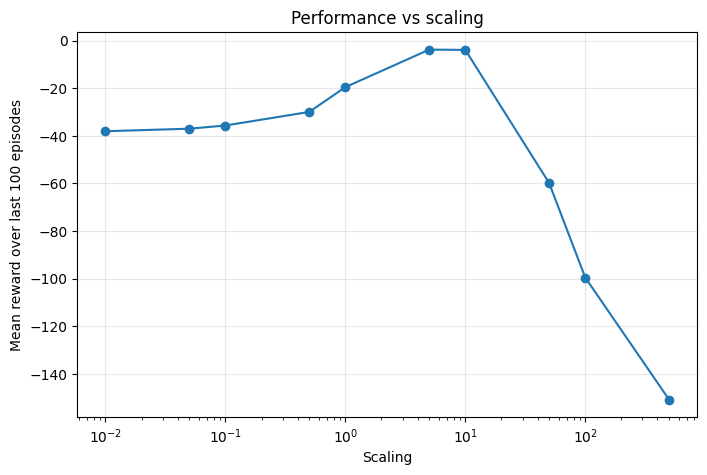

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

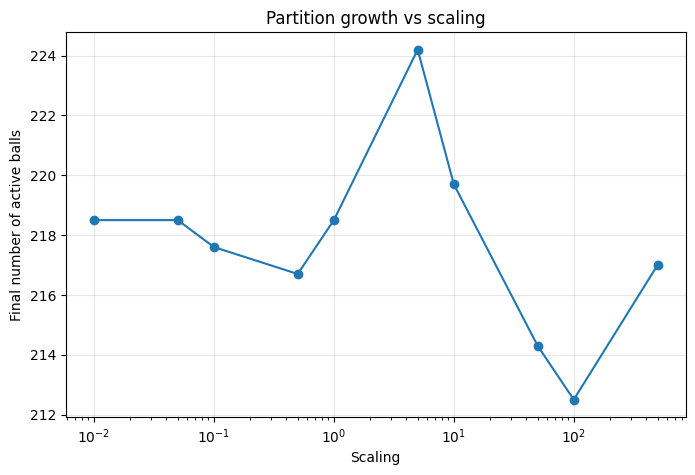

In [23]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

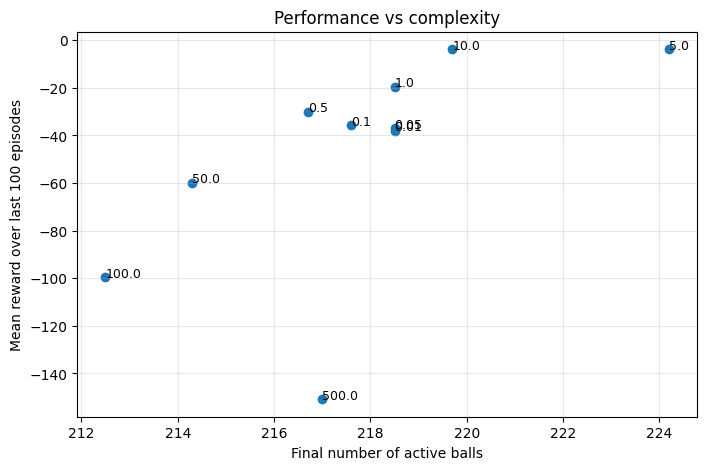

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: -36.580

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.651

--- Running: scaling=100 ---
    Done. Final mean VPI: -100.764


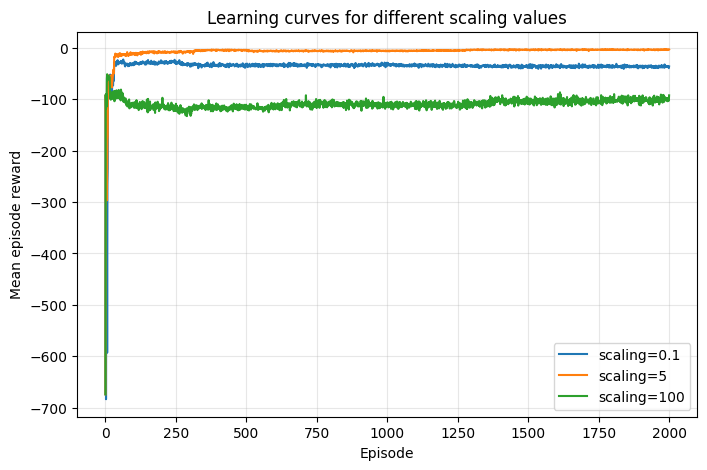

In [25]:
chosen_scalings = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")
plt.title("Learning curves for different scaling values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

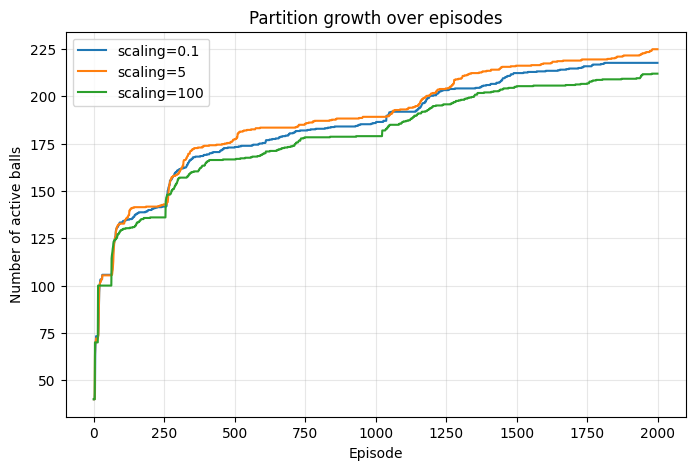

In [26]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Reward 2


In [45]:
importlib.reload(c)
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: 92.598

--- Running: scaling=0.05 ---
    Done. Final mean VPI: 92.652

--- Running: scaling=0.1 ---
    Done. Final mean VPI: 93.063

--- Running: scaling=0.5 ---
    Done. Final mean VPI: 95.457

--- Running: scaling=1 ---
    Done. Final mean VPI: 97.240

--- Running: scaling=5 ---
    Done. Final mean VPI: 91.089

--- Running: scaling=10 ---
    Done. Final mean VPI: 83.152

--- Running: scaling=50 ---
    Done. Final mean VPI: 57.932

--- Running: scaling=100 ---
    Done. Final mean VPI: 45.689

--- Running: scaling=500 ---
    Done. Final mean VPI: 36.498


In [46]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,185640.051680,92.598100,220.6,219.184
1,0.05,185834.821700,92.652033,219.4,217.951
2,0.10,186697.174160,93.062786,218.8,217.315
3,0.50,190854.430669,95.457347,220.0,218.323
4,1.00,193492.413931,97.239675,219.4,217.699
5,5.00,180918.325441,91.088684,208.3,208.069
6,10.00,164100.239988,83.151768,209.5,208.483
7,50.00,113823.956097,57.931826,211.6,211.600
8,100.00,91373.152053,45.688554,213.1,213.100
9,500.00,79744.457007,36.497663,217.0,217.000


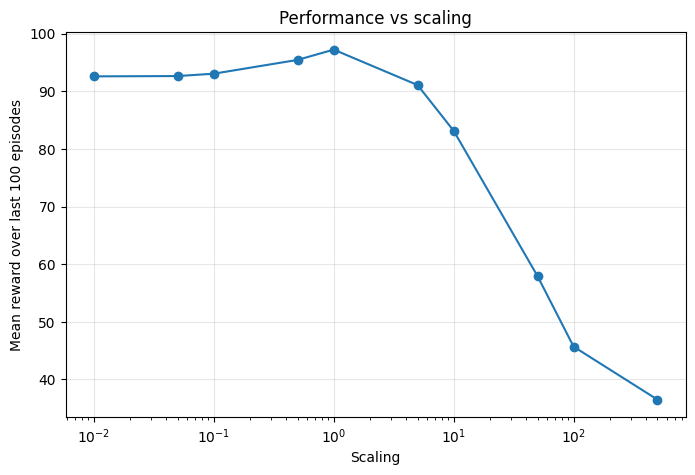

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

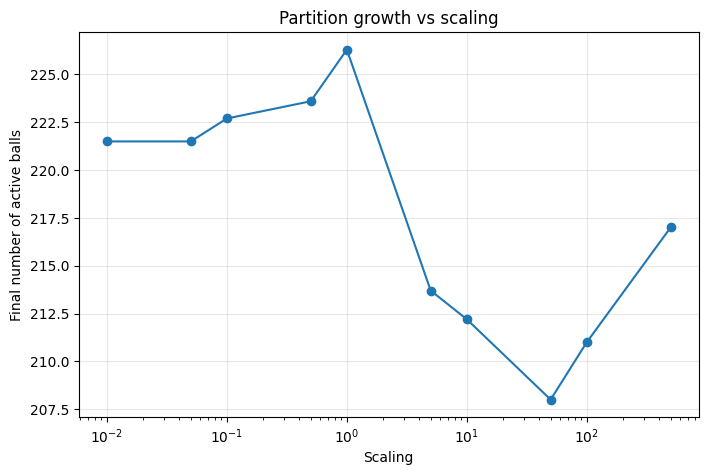

In [30]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

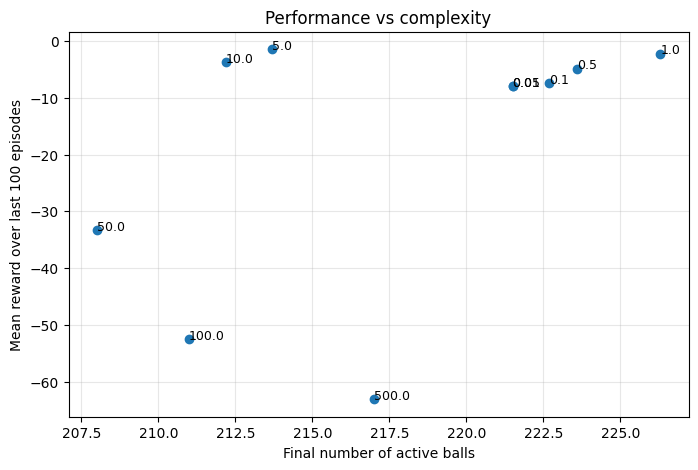

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: 93.298

--- Running: scaling=5 ---
    Done. Final mean VPI: 91.274

--- Running: scaling=100 ---
    Done. Final mean VPI: 44.868


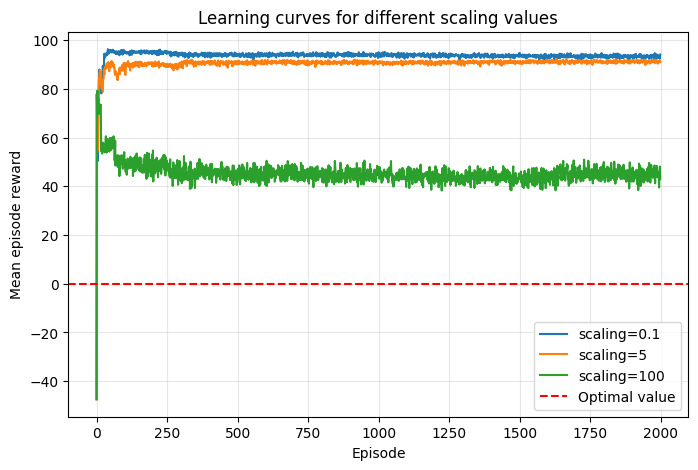

In [48]:
chosen_scalings = [0.1, 5, 100]



configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)
plt.axhline(y=0, color='red', linestyle='--', label='Optimal value')
plt.xlabel("Episode")
plt.ylabel("Mean episode reward")
plt.title("Learning curves for different scaling values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

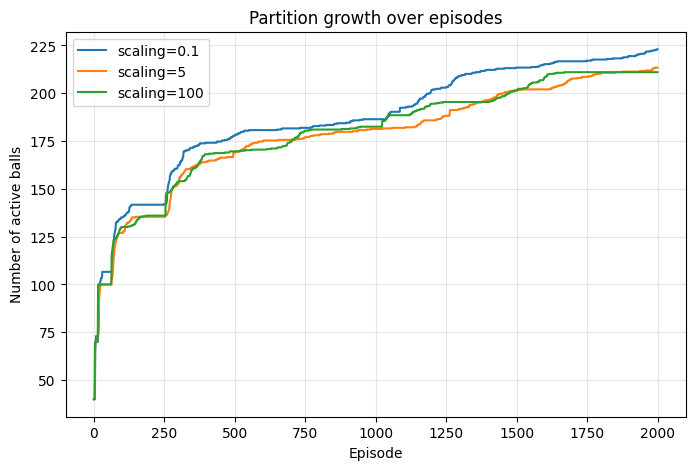

In [33]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Reward 3

In [34]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -42.483

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -41.932

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -41.404

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -34.968

--- Running: scaling=1 ---
    Done. Final mean VPI: -30.314

--- Running: scaling=5 ---
    Done. Final mean VPI: -8.964

--- Running: scaling=10 ---
    Done. Final mean VPI: -4.852

--- Running: scaling=50 ---
    Done. Final mean VPI: -30.342

--- Running: scaling=100 ---
    Done. Final mean VPI: -67.733

--- Running: scaling=500 ---
    Done. Final mean VPI: -213.679


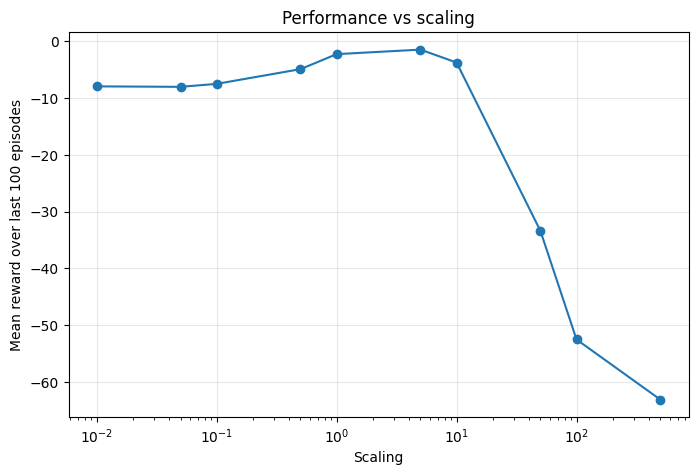

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-107864.873886,-42.483227,217.3,216.862
1,0.05,-107089.532766,-41.931611,218.8,218.692
2,0.10,-107357.407138,-41.403925,218.2,217.855
3,0.50,-93614.577309,-34.968308,218.8,218.659
4,1.00,-84212.993062,-30.313636,218.5,218.500
5,5.00,-36447.523876,-8.963805,218.5,217.615
6,10.00,-27678.493182,-4.851752,211.9,210.529
7,50.00,-87314.590244,-30.341543,210.7,210.700
8,100.00,-178551.273297,-67.733040,216.4,215.839
9,500.00,-406336.095909,-213.678907,217.0,217.000


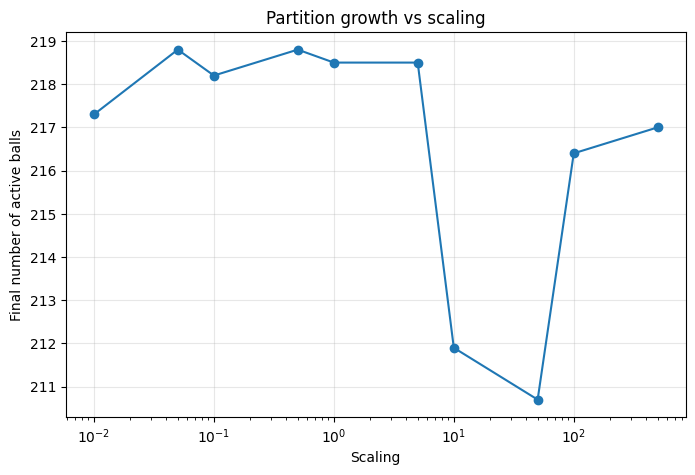

In [37]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

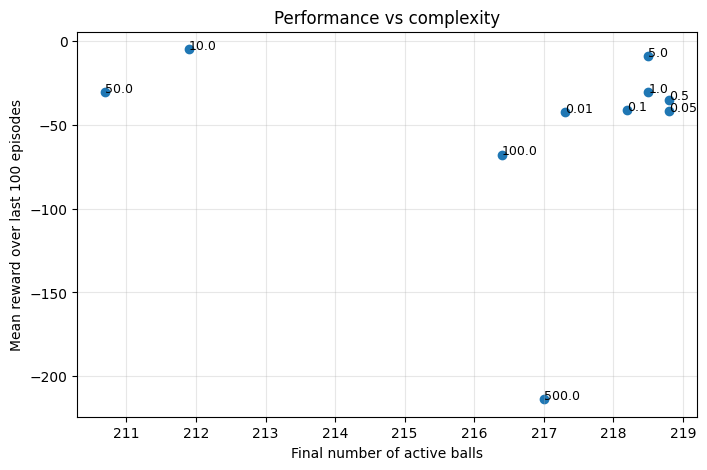

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: -41.462

--- Running: scaling=5 ---
    Done. Final mean VPI: -9.535

--- Running: scaling=100 ---
    Done. Final mean VPI: -68.414


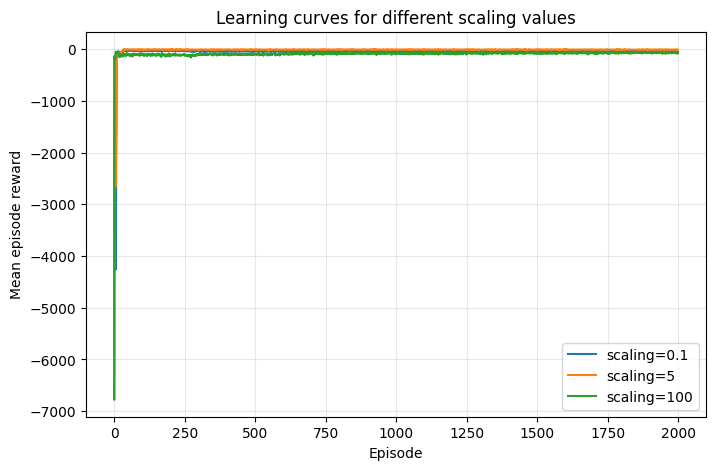

In [39]:
chosen_scalings = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")

plt.title("Learning curves for different scaling values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

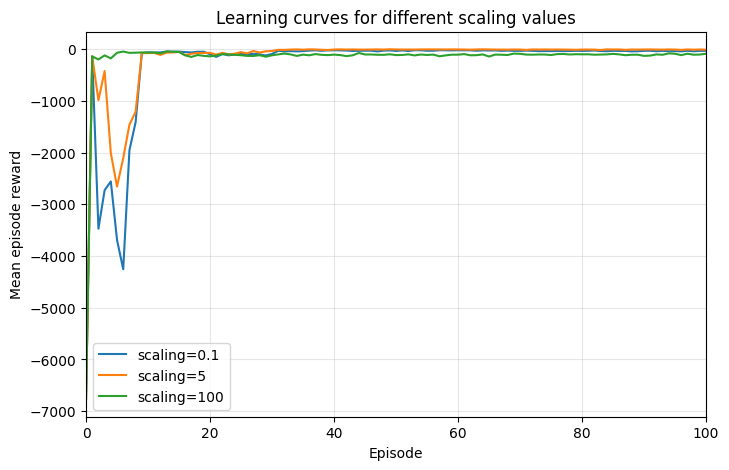

In [41]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")

plt.title("Learning curves for different scaling values")
plt.legend()
plt.xlim(0,100)
plt.grid(True, alpha=0.3)
plt.show()

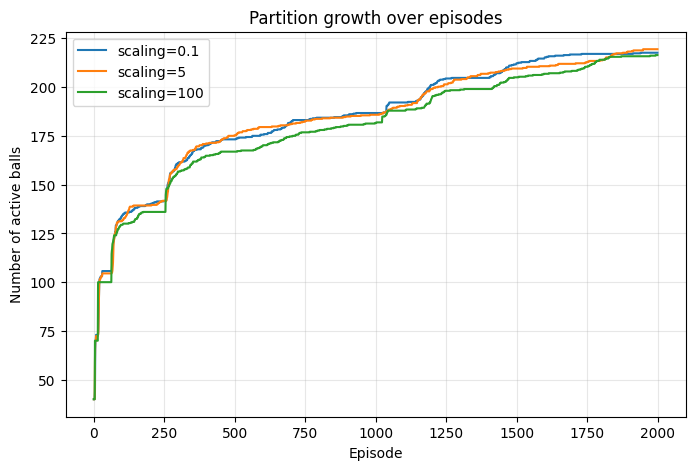

In [40]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()